In [59]:
import matplotlib as mpl
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import pearsonr
import math


In [22]:
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 6,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

hexcolors = [
    "#D1B8D7", "#AE76A3", "#882E72", "#1965B0", "#5289C7",
    "#7BAFDE", "#4EB265", "#90C987", "#CAE0AB", "#F7F056",
    "#F6C141", "#F1932D", "#E8601C", "#DC050C", "#777777",
]
colornames = [
    "purple1", "purple2", "purple3", "blue1", "blue2", "blue3",
    "green1", "green2", "green3", "yellow1", "yellow2", "orange1",
    "orange2", "red", "grey",
]
rnb_colors = dict(zip(colornames, hexcolors))

gradient_colors = [
    rnb_colors["blue2"],
    rnb_colors["green1"],
    rnb_colors["yellow2"],
    rnb_colors["red"],
]
cmap = mpl.colors.LinearSegmentedColormap.from_list("temp_gradient", gradient_colors, N=256)
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]


In [19]:
def pearsonr_bootstrapped(
    x: np.ndarray,
    y: np.ndarray,
    n_bootstraps: int = 10000,
    random_state: int | None = 42,) -> tuple[float, float]:
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    n_samples = len(x)
    if n_samples < 2:
        return np.nan, np.nan
    r_orig = pearsonr(x, y)[0]
    rng = np.random.default_rng(random_state)
    idx = rng.choice(n_samples, size=(n_bootstraps, n_samples), replace=True)
    x_boot, y_boot = x[idx], y[idx]
    dx = x_boot - np.mean(x_boot, axis=1, keepdims=True)
    dy = y_boot - np.mean(y_boot, axis=1, keepdims=True)
    cov = np.sum(dx * dy, axis=1)
    var_x = np.sum(dx**2, axis=1)
    var_y = np.sum(dy**2, axis=1)
    denom = np.sqrt(var_x * var_y)
    valid = denom > 0
    r_boot = np.full(n_bootstraps, np.nan)
    r_boot[valid] = cov[valid] / denom[valid]
    return float(r_orig), float(np.nanstd(r_boot, ddof=1))

In [38]:
# Simulation data loading
sim_files = [
    {"lipid": "DOPC", "T": 293.15, "file": "data/lipid_scan/DOPC_100_T_293.15_bilayer_prop.csv"},
    {"lipid": "DOPC", "T": 303.15, "file": "data/lipid_scan/DOPC_100_T_303.15_bilayer_prop.csv"},
    {"lipid": "POPC", "T": 293.15, "file": "data/lipid_scan/POPC_100_T_293.15_bilayer_prop.csv"},
    {"lipid": "POPC", "T": 303.15, "file": "data/lipid_scan/POPC_100_T_303.15_bilayer_prop.csv"},
    {"lipid": "POPC", "T": 323.15, "file": "data/lipid_scan/POPC_100_T_323.15_bilayer_prop.csv"},
    {"lipid": "POPC", "T": 333.15, "file": "data/lipid_scan/POPC_100_T_333.15_bilayer_prop.csv"},
    {"lipid": "POPS", "T": 298.15, "file": "data/lipid_scan/POPS_100_T_298.15_bilayer_prop.csv"},
    {"lipid": "POPS", "T": 308.15, "file": "data/lipid_scan/POPS_100_T_308.15_bilayer_prop.csv"},
    {"lipid": "POPS", "T": 318.15, "file": "data/lipid_scan/POPS_100_T_318.15_bilayer_prop.csv"},
    {"lipid": "POPS", "T": 328.15, "file": "data/lipid_scan/POPS_100_T_328.15_bilayer_prop.csv"}
]

# Reference data
T_ref = {
    ("DOPC", 293.15): {
        "apl": 64.3,
        "apl_err": 1.3,
        "apl_mart": 63.6,
        "apl_mart_err": 0.43,
        "dpp": 3.94,
        "dpp_err": 0.08
    },
    ("DOPC", 303.15): {
        "apl": 66.9,
        "apl_err": 1.0,
        "apl_mart": 65.3,
        "apl_mart_err": 0.45,
        "dpp": 3.89,
        "dpp_err": 0.08
    },
    ("POPC", 293.15): {
        "apl": 62.7,
        "apl_err": 1.3,
        "apl_mart": 57.8,
        "apl_mart_err": 0.58,
        "dpp": 3.98,
        "dpp_err": 0.08
    },
    ("POPC", 303.15): {
        "apl": 64.3,
        "apl_err": 1.3,
        "apl_mart": 60.0,
        "apl_mart_err": 0.57,
        "dpp": 3.91,
        "dpp_err": 0.08
    },
    ("POPC", 323.15): {
        "apl": 67.3,
        "apl_err": 1.3,
        "apl_mart": 63.8,
        "apl_mart_err": 0.41,
        "dpp": 3.79,
        "dpp_err": 0.08
    },
    ("POPC", 333.15): {
        "apl": 68.1,
        "apl_err": 1.4,
        "apl_mart": 65.4,
        "apl_mart_err": 0.48,
        "dpp": 3.77,
        "dpp_err": 0.08
    },
    ("POPS", 298.15): {
        "apl": 62.7,
    },
    ("POPS", 308.15): {
        "apl": 63.9,
    },
    ("POPS", 318.15): {
        "apl": 65.5,
    },
    ("POPS", 328.15): {
        "apl": 67.4,
    }
}

rows = []

for sim in sim_files:
    lipid, temp, file_path = sim["lipid"], sim["T"], sim["file"]
    ref_data = T_ref[(lipid, temp)]

    df_sim = pd.read_csv(file_path, header=0, names=["metric", "value", "error"]).set_index("metric")

    apl_val = df_sim.loc["apl", "value"]
    apl_val = apl_val * 100  # Convert to Å²
    apl_err = df_sim.loc["apl", "error"]
    apl_err = apl_err * 100 


    dpp_val = df_sim.loc["dpp", "value"]
    dpp_err = df_sim.loc["dpp", "error"]

    rows.append({
        "lipid": lipid,
        "T": temp,
        "apl_sim": apl_val,
        "apl_sim_err": apl_err,
        "apl_mart": ref_data.get("apl_mart"),
        "apl_mart_err": ref_data.get("apl_mart_err"),
        "dpp_sim": dpp_val,
        "dpp_sim_err": dpp_err,
        "apl_ref": ref_data.get("apl"),
        "apl_ref_err": ref_data.get("apl_err"),
        "dpp_ref": ref_data.get("dpp"),
        "dpp_ref_err": ref_data.get("dpp_err")
    })

lipid_temp_df = pd.DataFrame(rows)


#Plot normalizations
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
all_lipids = sorted(lipid_temp_df["lipid"].dropna().unique())
marker_map = {
    lip: marker_cycle[i % len(marker_cycle)]
    for i, lip in enumerate(all_lipids)
}
norm = plt.Normalize(lipid_temp_df["T"].dropna().min(), lipid_temp_df["T"].dropna().max())
all_apl = pd.concat([lipid_temp_df["apl_ref"], lipid_temp_df["apl_sim"], lipid_temp_df["apl_sim"]]).dropna()
apl_lims = (all_apl.min() - 7.0, all_apl.max() + 2.0)
norm = plt.Normalize(lipid_temp_df["T"].dropna().min(), lipid_temp_df["T"].dropna().max())

lipid_temp_df


,lipid,T,apl_sim,apl_sim_err,apl_mart,apl_mart_err,dpp_sim,dpp_sim_err,apl_ref,apl_ref_err,dpp_ref,dpp_ref_err
0,DOPC,293.15,65.774430,0.177722,63.6,0.43,3.95350,0.009271,64.3,1.3,3.94,0.08
1,DOPC,303.15,67.165740,0.098634,65.3,0.45,3.90700,0.009928,66.9,1.0,3.89,0.08
2,POPC,293.15,63.631020,0.097892,57.8,0.58,4.01625,0.008411,62.7,1.3,3.98,0.08
3,POPC,303.15,64.525280,0.120319,60.0,0.57,4.00725,0.008204,64.3,1.3,3.91,0.08
4,POPC,323.15,67.818373,0.171703,63.8,0.41,3.91775,0.010070,67.3,1.3,3.79,0.08
5,POPC,333.15,69.489640,0.138184,65.4,0.48,3.87925,0.009343,68.1,1.4,3.77,0.08
6,POPS,298.15,64.879750,0.147393,NaN,NaN,3.96075,0.009189,62.7,NaN,NaN,NaN
7,POPS,308.15,66.234990,0.121176,NaN,NaN,3.93350,0.008433,63.9,NaN,NaN,NaN
8,POPS,318.15,68.465820,0.083646,NaN,NaN,3.87950,0.009116,65.5,NaN,NaN,NaN
9,POPS,328.15,70.040050,0.177312,NaN,NaN,3.84925,0.010068,67.4,NaN,NaN,NaN


## Figure 2A

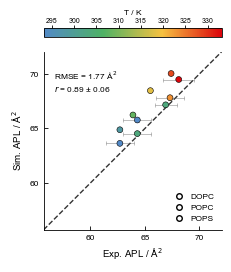

In [92]:
apl_t_df = lipid_temp_df.dropna(subset=["apl_ref", "apl_sim", "T", "lipid"]).copy()
apl_t_df["apl_ref_err"] = pd.to_numeric(apl_t_df["apl_ref_err"], errors="coerce").fillna(0)
apl_t_df["apl_sim_err"] = pd.to_numeric(apl_t_df["apl_sim_err"], errors="coerce").fillna(0)

fig, ax = plt.subplots(figsize=(2.2, 2.5), constrained_layout=True)

for lipid, sub in apl_t_df.groupby("lipid"):
    ax.scatter(
        sub["apl_ref"],
        sub["apl_sim"],
        c=sub["T"],
        cmap=cmap,
        norm=norm,
        marker=marker_map[lipid],
        edgecolors="k",
        linewidth=0.4,
        s=18,
        zorder=10,
    )

ax.errorbar(
    apl_t_df["apl_ref"],
    apl_t_df["apl_sim"],
    xerr=apl_t_df["apl_ref_err"],
    yerr=apl_t_df["apl_sim_err"],
    fmt="none",
    ecolor="0.35",
    elinewidth=0.5,
    capsize=1.5,
    capthick=0.5,
    alpha=0.55,
    zorder=2,
)


ax.plot(apl_lims, apl_lims, "--", color="0.2", lw=1.0, zorder=1)

ax.set_xlim(apl_lims)
ax.set_ylim(apl_lims)
ax.set_aspect("equal", adjustable="box")
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.tick_params(direction="in", length=3, width=0.6)
ax.set_xlabel("Exp. APL / Å$^2$")
ax.set_ylabel("Sim. APL / Å$^2$")

# 5. RMSE and Pearson Correlation Statistics
x_vals = apl_t_df["apl_ref"].values
y_vals = apl_t_df["apl_sim"].values
rmsd = np.sqrt(np.mean((y_vals - x_vals) ** 2))

r_orig, r_err = pearsonr_bootstrapped(x_vals, y_vals, n_bootstraps=10000, random_state=42)

ax.annotate(f"RMSE = {rmsd:.2f} Å$^2$\n$r$ = {r_orig:.2f} ± {r_err:.2f}", (0.06, 0.90), xycoords="axes fraction", fontsize=6, ha="left", va="top", bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.85, lw=0))

lipids_here = sorted(apl_t_df["lipid"].unique())
handles = [
    mlines.Line2D([], [], color="k", marker=marker_map[l], linestyle="None", markersize=4, markerfacecolor="white", label=l)
    for l in lipids_here
]
ax.legend(handles=handles, loc="lower right", frameon=False, handletextpad=0.3)

# Temperature Colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="5%", pad=0.15)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
cb.ax.tick_params(labelsize=5, length=2, pad=1)
cb.set_label("T / K", fontsize=6, labelpad=2)
cax.xaxis.set_label_position("top")
cax.xaxis.set_ticks_position("top")


plt.show()

## Figure 2B

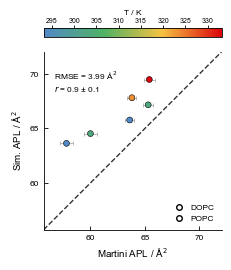

In [ ]:
apl_t_martini = lipid_temp_df.dropna(subset=["apl_mart", "apl_sim", "T", "lipid"]).copy()
apl_t_martini["apl_mart_err"] = pd.to_numeric(apl_t_martini["apl_mart_err"], errors="coerce").fillna(0)
apl_t_martini["apl_sim_err"] = pd.to_numeric(apl_t_martini["apl_sim_err"], errors="coerce").fillna(0)

fig, ax = plt.subplots(figsize=(2.2, 2.5), constrained_layout=True)

# 1. Errorbars
ax.errorbar(
    apl_t_martini["apl_mart"],
    apl_t_martini["apl_sim"],
    xerr=apl_t_martini["apl_mart_err"],
    yerr=apl_t_martini["apl_sim_err"],
    fmt="none",
    ecolor="0.35",
    elinewidth=0.5,
    capsize=1.5,
    capthick=0.5,
    alpha=0.55,
    zorder=2,
)

# 2. Scatter points grouped by lipid
for lipid, sub in apl_t_martini.groupby("lipid"):
    ax.scatter(
        sub["apl_mart"],
        sub["apl_sim"],
        c=sub["T"],
        cmap=cmap,
        norm=norm,
        marker=marker_map[lipid],
        edgecolors="k",
        linewidth=0.4,
        s=18,
        zorder=10,
    )

# 3. Line of identity
ax.plot(apl_lims, apl_lims, "--", color="0.2", lw=1.0, zorder=1)

# 4. Axes, ticks, and labels
ax.set_xlim(apl_lims)
ax.set_ylim(apl_lims)
ax.set_aspect("equal", adjustable="box")
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.tick_params(direction="in", length=3, width=0.6)

ax.set_xlabel("Martini APL / Å$^2$")
ax.set_ylabel("Sim. APL / Å$^2$")

# 5. RMSE and Pearson Correlation Statistics
x_vals = apl_t_martini["apl_mart"].values
y_vals = apl_t_martini["apl_sim"].values
rmsd = np.sqrt(np.mean((y_vals - x_vals) ** 2))

r_orig, r_err = pearsonr_bootstrapped(x_vals, y_vals, n_bootstraps=10000, random_state=42)

ax.annotate(f"RMSE = {rmsd:.2f} Å$^2$\n$r$ = {r_orig:.1f} ± {r_err:.1f}", (0.06, 0.90), xycoords="axes fraction", fontsize=6, ha="left", va="top", bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.85, lw=0))


# 6. Legend
lipids_here = sorted(apl_t_martini["lipid"].unique())
handles = [
    mlines.Line2D([], [], color="k", marker=marker_map[l], linestyle="None", markersize=4, markerfacecolor="white", label=l)
    for l in lipids_here
]
ax.legend(handles=handles, loc="lower right", frameon=False, handletextpad=0.3)

# 7. Temperature Colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="5%", pad=0.15)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
cb.ax.tick_params(labelsize=5, length=2, pad=1)
cb.set_label("T / K", fontsize=6, labelpad=2)
cax.xaxis.set_label_position("top")
cax.xaxis.set_ticks_position("top")

plt.show()

## Figure 2C

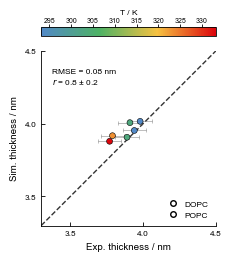

In [94]:
dpp_t_df = lipid_temp_df.dropna(subset=["dpp_ref", "dpp_sim", "T", "lipid"]).copy()
dpp_t_df["dpp_ref_err"] = pd.to_numeric(dpp_t_df["dpp_ref_err"], errors="coerce").fillna(0)
dpp_t_df["dpp_sim_err"] = pd.to_numeric(dpp_t_df["dpp_sim_err"], errors="coerce").fillna(0)

# Dynamic axis limits for thickness
thick_vals = pd.concat([dpp_t_df["dpp_ref"], dpp_t_df["dpp_sim"]]).dropna()

fig, ax = plt.subplots(figsize=(2.2, 2.5), constrained_layout=True)

# 1. Errorbars
ax.errorbar(
    dpp_t_df["dpp_ref"],
    dpp_t_df["dpp_sim"],
    xerr=dpp_t_df["dpp_ref_err"],
    yerr=dpp_t_df["dpp_sim_err"],
    fmt="none",
    ecolor="0.35",
    elinewidth=0.5,
    capsize=1.5,
    capthick=0.5,
    alpha=0.55,
    zorder=2,
)

# 2. Scatter points grouped by lipid
for lipid, sub in dpp_t_df.groupby("lipid"):
    ax.scatter(
        sub["dpp_ref"],
        sub["dpp_sim"],
        c=sub["T"],
        cmap=cmap,
        norm=norm,
        marker=marker_map[lipid],
        edgecolors="k",
        linewidth=0.4,
        s=18,
        zorder=10,
    )

# 3. Line of identity
ax.plot([3.3, 4.5], [3.3, 4.5], "--", color="0.2", lw=1.0, zorder=1)

# 4. Axes, ticks, and labels
ax.set_xlim(3.3, 4.5)
ax.set_ylim(3.3, 4.5)
ax.set_aspect("equal", adjustable="box")
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.tick_params(direction="in", length=3, width=0.6)

ax.set_xlabel("Exp. thickness / nm")
ax.set_ylabel("Sim. thickness / nm")

# 5. RMSE and Pearson Correlation Statistics
x_vals = dpp_t_df["dpp_ref"].values
y_vals = dpp_t_df["dpp_sim"].values
rmsd = np.sqrt(np.mean((y_vals - x_vals) ** 2))

r_orig, r_err = pearsonr_bootstrapped(x_vals, y_vals, n_bootstraps=10000, random_state=42)

ax.annotate(
    f"RMSE = {rmsd:.2f} nm\n$r$ = {r_orig:.1f} ± {r_err:.1f}",
    (0.06, 0.90),
    xycoords="axes fraction",
    fontsize=6,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.85, lw=0),
)

# 6. Legend
lipids_here = sorted(dpp_t_df["lipid"].unique())
handles = [
    mlines.Line2D([], [], color="k", marker=marker_map[l], linestyle="None", markersize=4, markerfacecolor="white", label=l)
    for l in lipids_here
]
ax.legend(handles=handles, loc="lower right", frameon=False, handletextpad=0.3)

# 7. Temperature Colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("top", size="5%", pad=0.15)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = plt.colorbar(sm, cax=cax, orientation="horizontal")
cb.ax.tick_params(labelsize=5, length=2, pad=1)
cb.set_label("T / K", fontsize=6, labelpad=2)
cax.xaxis.set_label_position("top")
cax.xaxis.set_ticks_position("top")


plt.show()

## Figure 2D

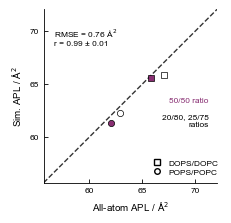

In [95]:
ref_aa_apl = {
    ("POPS_POPC", 20): {"apl_ref": 62.87, "dpp_ref": 3.79},
    ("POPS_POPC", 50): {"apl_ref": 62.07, "dpp_ref": 3.83},
    ("DOPS_DOPC", 25): {"apl_ref": 67.00, "dpp_ref": 3.43},
    ("DOPS_DOPC", 50): {"apl_ref": 65.80, "dpp_ref": 3.86},
}

sim_aa_apl = {
    'POPS_20_POPC_80': 'data/lipid_scan/POPS_20_POPC_80_sigma_0.65_l_0.437_bilayer_prop.csv',
    'POPS_50_POPC_50': 'data/lipid_scan/POPS_50_POPC_50_sigma_0.65_l_0.437_bilayer_prop.csv',
    'DOPS_25_DOPC_75': 'data/lipid_scan/DOPS_25_DOPC_75_sigma_0.65_l_0.437_bilayer_prop.csv',
    'DOPS_50_DOPC_50': 'data/lipid_scan/DOPS_50_DOPC_50_sigma_0.65_l_0.437_bilayer_prop.csv'
}

dfs = []
for label, path in sim_aa_apl.items():
    df = pd.read_csv(path, index_col=0)
    apl_val = df.loc['apl', 'value'] 
    apl_err_val = df.loc['apl', 'error'] 
    parts = label.split('_')
    pair = f"{parts[0]}_{parts[2]}"
    ratio = int(parts[1])
    dfs.append({
        'pair': pair,
        'ratio': ratio,
        'apl': apl_val,
        'apl_err': apl_err_val
    })

df_aa = pd.DataFrame(dfs)

# Map reference values directly
df_aa["apl_ref"] = df_aa.apply(
    lambda row: ref_aa_apl.get((row["pair"], int(row["ratio"])), {}).get("apl_ref", np.nan)
    if pd.notna(row["ratio"]) else np.nan,
    axis=1,
)

# Scale nm^2 to Å^2 (0.6225 nm^2 -> 62.25 Å^2)
scale_sim_apl = 100.0  
pdf_d = df_aa.dropna(subset=["apl_ref", "apl", "pair", "ratio"]).copy()

x_vals = pd.to_numeric(pdf_d["apl_ref"], errors="coerce").values
y_vals = pd.to_numeric(pdf_d["apl"], errors="coerce").values * scale_sim_apl
y_errs = pd.to_numeric(pdf_d["apl_err"], errors="coerce").fillna(0).values * scale_sim_apl
pairs = pdf_d["pair"].astype(str).values
ratios = pd.to_numeric(pdf_d["ratio"], errors="coerce").values

# Filter out non-finite indices
m = np.isfinite(x_vals) & np.isfinite(y_vals) & np.isfinite(y_errs)
x_vals, y_vals, y_errs, pairs, ratios = x_vals[m], y_vals[m], y_errs[m], pairs[m], ratios[m]

fig, ax = plt.subplots(figsize=(2.2, 2.5), constrained_layout=True)

marker_map_d = {"DOPS_DOPC": "s", "POPS_POPC": "o"}
fill_col = rnb_colors["purple3"]

for xi, yi, yei, p, r in zip(x_vals, y_vals, y_errs, pairs, ratios):
    mk = marker_map_d.get(p, "o")
    filled = int(r) in [40, 50]
    mfc = fill_col if filled else "white"

    ax.errorbar(xi, yi, yerr=yei, xerr=None, fmt=mk, ms=4.5, mfc=mfc, mec="k", mew=0.5, ecolor="0.35", elinewidth=0.5, capsize=1.5, capthick=0.5, zorder=3)

ax.plot(apl_lims, apl_lims, "--", color="0.2", lw=1.0, zorder=1)

ax.set_xlim(apl_lims)
ax.set_ylim(apl_lims)
ax.set_aspect("equal", adjustable="box")
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.tick_params(direction="in", length=3, width=0.6)

ax.set_xlabel("All-atom APL / Å$^2$")
ax.set_ylabel("Sim. APL / Å$^2$")

rmsd = np.sqrt(np.mean((y_vals - x_vals) ** 2))

r_orig, r_err = pearsonr_bootstrapped(x_vals, y_vals, n_bootstraps=10000, random_state=42)

ax.annotate(
    f"RMSE = {rmsd:.2f} Å$^2$\nr = {r_orig:.2f} ± {r_err:.2f}",
    (0.06, 0.90),
    xycoords="axes fraction",
    fontsize=6,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.85, lw=0),
)

handles_all = [
    mlines.Line2D([], [], color="k", marker="s", linestyle="None", markerfacecolor="white", markersize=4, label="DOPS/DOPC"),
    mlines.Line2D([], [], color="k", marker="o", linestyle="None", markerfacecolor="white", markersize=4, label="POPS/POPC"),
]

ax.legend(
    handles=handles_all,
    loc="lower right",
    bbox_to_anchor=(1.05, 0.0),
    frameon=False,
    handletextpad=0.3,
    labelspacing=0.25,
)

ax.annotate("50/50 ratio", xy=(0.95, 0.46), xycoords="axes fraction", fontsize=6, ha="right", va="bottom", color=fill_col)
ax.annotate("20/80, 25/75\nratios", xy=(0.95, 0.32), xycoords="axes fraction", fontsize=6, ha="right", va="bottom", color="k")

plt.show()

## Figure S1

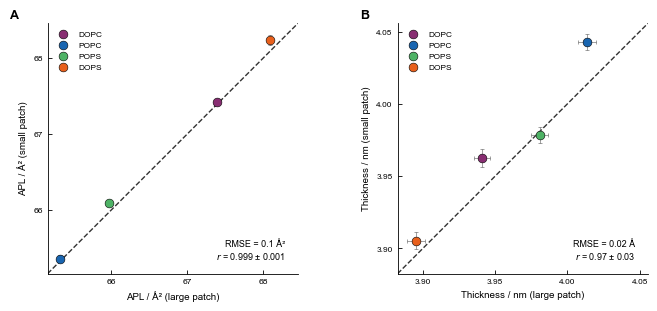

In [ ]:
from matplotlib import ticker

rows = []
for patch in ['big', 'small']:
    for lipid in ['DOPC', 'POPC', 'DOPS', 'POPS']:
        df = pd.read_csv(f'data/lipid_scan/fse/{patch}/{lipid}_bilayer_prop.csv', index_col=0)
        sysname = f'{lipid}_{patch}'
        rows.append({
            'sysname': sysname,
            'apl': df.loc['apl', 'value'],
            'apl_err': df.loc['apl', 'error'],
            'dpp': df.loc['dpp', 'value'],
            'dpp_err': df.loc['dpp', 'error'],
        })
fse = pd.DataFrame(rows).set_index('sysname')

lipids = ['DOPC', 'POPC', 'POPS', 'DOPS']

colors = {
    'DOPC': rnb_colors['purple3'],
    'POPC': rnb_colors['blue1'],
    'POPS': rnb_colors['green1'],
    'DOPS': rnb_colors['orange2']
}

marker_map = {
    'DOPC': 'o',
    'POPC': 'o',
    'POPS': 'o',
    'DOPS': 'o',
}

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

# Loop over each lipid and plot points + error bars
for lipid in lipids:
    big = fse.loc[f'{lipid}_big']
    small = fse.loc[f'{lipid}_small']

    for a, key, scale in zip(ax, ['apl', 'dpp'], [100, 1]):
        # Convert scalar values safely
        x = float(big[key]) * scale
        y = float(small[key]) * scale
        xe = float(big[f'{key}_err']) * scale
        ye = float(small[f'{key}_err']) * scale

        a.errorbar(x, y, xerr=xe, yerr=ye, fmt='none', ecolor='0.35', elinewidth=0.5, capsize=1.5, capthick=0.5, alpha=0.8, zorder=2)
        a.scatter(x, y, marker='o', facecolor=colors[lipid], edgecolors='k', linewidth=0.4, s=40, label=lipid, zorder=10)

# Axis styling and diagonal reference lines
for a, label in zip(ax, ['APL / Å²', 'Thickness / nm']):
    a.set_xlabel(f'{label} (large patch)')
    a.set_ylabel(f'{label} (small patch)')
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.tick_params(direction='in', length=3, width=0.6)

    lims = [min(a.get_xlim()[0], a.get_ylim()[0]), max(a.get_xlim()[1], a.get_ylim()[1])]
    a.plot(lims, lims, '--', color='0.2', lw=1.0, zorder=1)
    a.set_aspect('equal', adjustable='box')
    a.set_xlim(lims)
    a.set_ylim(lims)

# Set tick locators
ax[0].yaxis.set_major_locator(ticker.MultipleLocator(1))
ax[0].xaxis.set_major_locator(ticker.MultipleLocator(1))
ax[1].yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax[1].xaxis.set_major_locator(ticker.MultipleLocator(0.05))

# Legends (Placed in upper left)
ax[0].legend(frameon=False, loc='upper left')
ax[1].legend(frameon=False, loc='upper left')

# Annotations (Placed in bottom right to avoid legend collision)
apl_big = np.array([fse.loc[f'{l}_big', 'apl'] for l in lipids]) * 100
apl_small = np.array([fse.loc[f'{l}_small', 'apl'] for l in lipids]) * 100

ax[0].annotate(
    "RMSE = {:.1f} Å²\n$r$ = {:.3f} ± {:.3f}".format(
        np.sqrt(np.mean((apl_big - apl_small)**2)),
        *pearsonr_bootstrapped(apl_big, apl_small)
    ),
    xy=(0.95, 0.05),
    xycoords='axes fraction',
    fontsize=6.5,
    ha='right',
    va='bottom',
    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85, lw=0),
)

dpp_big = np.array([fse.loc[f'{l}_big', 'dpp'] for l in lipids])
dpp_small = np.array([fse.loc[f'{l}_small', 'dpp'] for l in lipids])

ax[1].annotate(
    "RMSE = {:.2f} Å\n$r$ = {:.2f} ± {:.2f}".format(
        np.sqrt(np.mean((dpp_big - dpp_small)**2)),
        *pearsonr_bootstrapped(dpp_big, dpp_small)
    ),
    xy=(0.95, 0.05),
    xycoords='axes fraction',
    fontsize=6.5,
    ha='right',
    va='bottom',
    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85, lw=0),
)

ax[0].text(-0.15, 1.02, 'A', transform=ax[0].transAxes, fontweight='bold', fontsize=9)
ax[1].text(-0.15, 1.02, 'B', transform=ax[1].transAxes, fontweight='bold', fontsize=9)


plt.show()

## Figure S2

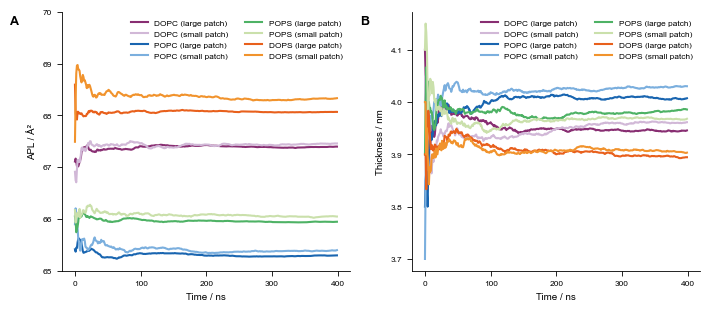

In [68]:
lipids = ['DOPC', 'POPC', 'POPS', 'DOPS']
patch = ['big', 'small']

patch_dict = {'big': 'large patch', 'small': 'small patch'}

lipid_colors = {
    'DOPC': (rnb_colors['purple3'], rnb_colors['purple1']),  # (big, small)
    'POPC': (rnb_colors['blue1'],   rnb_colors['blue3']),
    'POPS': (rnb_colors['green1'],  rnb_colors['green3']),
    'DOPS': (rnb_colors['orange2'], rnb_colors['orange1'])
}

# Line styles to visually separate big and small
patch_linestyle = {'big': '-', 'small': '-'}

apl_dict = {}
dpp_dict = {}

# Load and calculate cumulative averages
for lipid in lipids:
    for p in patch:
        apl = np.load(
            f'data/lipid_scan/fse/{p}/{lipid}_apl.npy'
        )
        dpp = np.load(
            f'data/lipid_scan/fse/{p}/{lipid}_dpp.npy'
        )

        # Store using a tuple key (lipid, patch)
        key = (lipid, p)
        apl_dict[key] = np.cumsum(apl) / np.arange(1, len(apl) + 1)
        dpp_dict[key] = np.cumsum(dpp) / np.arange(1, len(dpp) + 1)
        

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)

for lipid in lipids:
    for idx, p in enumerate(patch):
        key = (lipid, p)
        color = lipid_colors[lipid][idx]  # Pick color variant for patch size
        ls = patch_linestyle[p]
        label = f'{lipid} ({patch_dict[p]})'

        ax[0].plot(
            apl_dict[key] * 100,
            label=label,
            color=color,
            linestyle=ls
        )
    
        ax[1].plot(
            dpp_dict[key],
            label=label,
            color=color,
            linestyle=ls
        )

# Axis formatting
for a, ylabel in zip(ax, ['APL / Å²', 'Thickness / nm']):
    a.set_xlabel('Time / ns')
    a.set_ylabel(ylabel)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

ax[0].set_ylim(65, 70)

# Legend formatting
ax[0].legend(frameon=False, fontsize=6, ncol=2)
ax[0].xaxis.set_major_locator(ticker.MultipleLocator(100))
ax[1].legend(frameon=False, fontsize=6, ncol=2)
ax[1].xaxis.set_major_locator(ticker.MultipleLocator(100))

ax[0].text(
    -0.18, 0.95, 'A',
    transform=ax[0].transAxes,
    fontweight='bold',
    fontsize=9
)

ax[1].text(
    -0.18, 0.95, 'B',
    transform=ax[1].transAxes,
    fontweight='bold',
    fontsize=9
)
plt.show()

## Figure S3

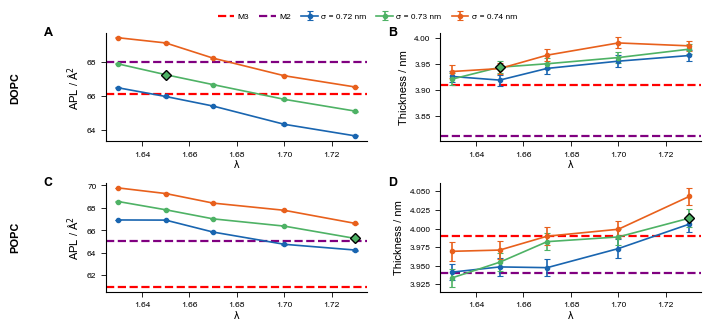

In [88]:
rows_tail = []
for lipid in ['DOPC', 'POPC']:
    for l in ['1.63', '1.65', '1.67', '1.7', '1.73']:
        for s in ['0.72', '0.73', '0.74']:
            df = pd.read_csv(
                f'data/lipid_scan/{lipid}_100_sigma_{s}_l_{l}_bilayer_prop.csv', index_col=0)
            rows_tail.append({
                'lipid': lipid, 'l': float(l), 'sigma': float(s),
                'apl': df.loc['apl', 'value'] * 100, 'apl_err': df.loc['apl', 'error'] * 100,
                'dpp': df.loc['dpp', 'value'], 'dpp_err': df.loc['dpp', 'error'],
            })

scan_tail = pd.DataFrame(rows_tail)

fig, axs = plt.subplots(2, 2, figsize=(7, 3.5))
fig.subplots_adjust(left=0.13, right=0.98, wspace=0.28, hspace=0.38, top=0.85)

sigma_colors_a = {0.72: rnb_colors['blue1'], 0.73: rnb_colors['green1'], 0.74: rnb_colors['orange2']}
chosen_param = {'DOPC': {'sigma': 0.73, 'l': 1.65}, 'POPC': {'sigma': 0.73, 'l': 1.73}}

for row, lipid in enumerate(['DOPC', 'POPC']):
    target = chosen_param[lipid]
    panel_apl, panel_dpp = axs[row, 0], axs[row, 1]
    
    for sigma, col in sigma_colors_a.items():
        sub = scan_tail[(scan_tail['lipid'] == lipid) & (scan_tail['sigma'] == sigma)].sort_values('l')
        
        panel_apl.errorbar(sub['l'], sub['apl'], yerr=sub['apl_err'], marker='o', ms=3,
                        lw=1.2, capsize=2, capthick=0.8, color=col, label=f'σ = {sigma} nm', zorder=3)
        panel_dpp.errorbar(sub['l'], sub['dpp'], yerr=sub['dpp_err'], marker='o', ms=3,
                        lw=1.2, capsize=2, capthick=0.8, color=col, label=f'σ = {sigma} nm', zorder=3)

        if abs(sigma - target['sigma']) < 1e-4:
            pt = sub[sub['l'].between(target['l'] - 1e-4, target['l'] + 1e-4)]
            if not pt.empty:
                panel_apl.plot(pt['l'], pt['apl'], marker='D', ms=5, mfc=col, mec='k', mew=1.0, zorder=6)
                panel_dpp.plot(pt['l'], pt['dpp'], marker='D', ms=5, mfc=col, mec='k', mew=1.0, zorder=6)

    for i, ax in enumerate((panel_apl, panel_dpp)):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)
        ax.set_xlabel('λ', fontsize=8, labelpad=2)
        ax.grid(False)
        
        letter = chr(ord('A') + row * 2 + i)
        ax.text(-0.24 if i == 0 else -0.20, 1.06, letter, transform=ax.transAxes,
                fontsize=9, weight='bold', va='top', ha='left', clip_on=False)

    panel_apl.set_ylabel('APL / Å$^2$', fontsize=8, labelpad=4)
    panel_dpp.set_ylabel('Thickness / nm', fontsize=8, labelpad=4)
    panel_apl.text(-0.35, 0.5, lipid, transform=panel_apl.transAxes, rotation=90,
                  va='center', ha='center', fontsize=8, weight='bold', clip_on=False)

# Reference Lines
axs[0, 0].axhline(66.1, ls='--', lw=1.6, color='red', label='M3')
axs[0, 0].axhline(68.0, ls='--', lw=1.6, color='purple', label='M2')
axs[0, 1].axhline(3.91, ls='--', lw=1.6, color='red', label='M3')
axs[0, 1].axhline(3.81, ls='--', lw=1.6, color='purple', label='M2')
axs[1, 0].axhline(61.0, ls='--', lw=1.6, color='red', label='M3')
axs[1, 0].axhline(65.1, ls='--', lw=1.6, color='purple', label='M2')
axs[1, 1].axhline(3.99, ls='--', lw=1.6, color='red', label='M3')
axs[1, 1].axhline(3.94, ls='--', lw=1.6, color='purple', label='M2')

axs[0, 0].legend(frameon=False, loc='lower center', bbox_to_anchor=(1, 1.05),
                 ncol=5, columnspacing=1.2, handletextpad=0.4)

plt.show()

## Figure S4

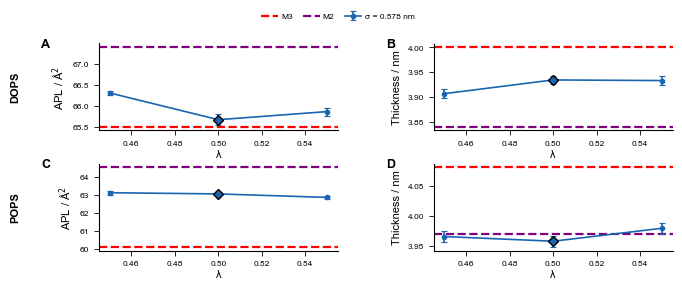

In [ ]:
rows_pho = []
for lipid in ['DOPS', 'POPS']:
    for l in ['0.45', '0.5', '0.55']:
        df = pd.read_csv(
            f'data/lipid_scan/{lipid}_100_sigma_0.578_l_{l}_bilayer_prop.csv', index_col=0)
        rows_pho.append({
            'lipid': lipid, 'l': float(l), 'sigma': 0.578,
            'apl': df.loc['apl', 'value'] * 100, 'apl_err': df.loc['apl', 'error'] * 100,
            'dpp': df.loc['dpp', 'value'], 'dpp_err': df.loc['dpp', 'error'],
        })

scan_pho = pd.DataFrame(rows_pho)

fig, axs = plt.subplots(2, 2, figsize=(7, 3))
fig.subplots_adjust(left=0.13, right=0.95, wspace=0.4, hspace=0.38, top=0.8)

chosen_param = {'DOPS': {'sigma': 0.578, 'l': 0.5}, 'POPS': {'sigma': 0.578, 'l': 0.5}}

for row, lipid in enumerate(['DOPS', 'POPS']):
    target = chosen_param[lipid]
    panel_apl, panel_dpp = axs[row, 0], axs[row, 1]
    col = rnb_colors['blue1']
    
    sub = scan_pho[scan_pho['lipid'] == lipid].sort_values('l')
    
    panel_apl.errorbar(sub['l'], sub['apl'], yerr=sub['apl_err'], marker='o', ms=3,
                    lw=1.2, capsize=2, capthick=0.8, color=col, label='σ = 0.578 nm', zorder=3)
    panel_dpp.errorbar(sub['l'], sub['dpp'], yerr=sub['dpp_err'], marker='o', ms=3,
                    lw=1.2, capsize=2, capthick=0.8, color=col, label='σ = 0.578 nm', zorder=3)

    pt = sub[sub['l'].between(target['l'] - 1e-4, target['l'] + 1e-4)]
    if not pt.empty:
        panel_apl.plot(pt['l'], pt['apl'], marker='D', ms=5, mfc=col, mec='k', mew=1.0, zorder=6)
        panel_dpp.plot(pt['l'], pt['dpp'], marker='D', ms=5, mfc=col, mec='k', mew=1.0, zorder=6)

    for i, ax in enumerate((panel_apl, panel_dpp)):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)
        ax.set_xlabel('λ', fontsize=8, labelpad=2)
        ax.grid(False)

        letter = chr(ord('A') + row * 2 + i)
        ax.text(-0.24 if i == 0 else -0.20, 1.06, letter, transform=ax.transAxes,
                fontsize=9, weight='bold', va='top', ha='left', clip_on=False)

    panel_apl.set_ylabel('APL / Å$^2$', fontsize=8, labelpad=4)
    panel_dpp.set_ylabel('Thickness / nm', fontsize=8, labelpad=4)
    panel_apl.text(-0.35, 0.5, lipid, transform=panel_apl.transAxes, rotation=90,
                  va='center', ha='center', fontsize=8, weight='bold', clip_on=False)

# Reference Lines
axs[0, 0].axhline(65.5, ls='--', lw=1.6, color='red', label='M3')
axs[0, 0].axhline(67.4, ls='--', lw=1.6, color='purple', label='M2')
axs[0, 1].axhline(4.00, ls='--', lw=1.6, color='red', label='M3')
axs[0, 1].axhline(3.84, ls='--', lw=1.6, color='purple', label='M2')
axs[1, 0].axhline(60.12, ls='--', lw=1.6, color='red', label='M3')
axs[1, 0].axhline(64.50, ls='--', lw=1.6, color='purple', label='M2')
axs[1, 1].axhline(4.08, ls='--', lw=1.6, color='red', label='M3')
axs[1, 1].axhline(3.97, ls='--', lw=1.6, color='purple', label='M2')

axs[0, 0].legend(frameon=False, loc='lower center', bbox_to_anchor=(1, 1.19),
                 ncol=3, columnspacing=1.2, handletextpad=0.4)

plt.show()

## Figure S5

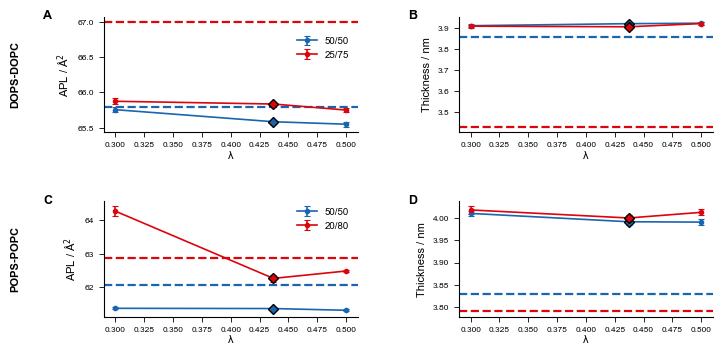

In [ ]:
rows_cho = []

# POPS/POPC Mixtures
for lipid in ['POPS_50_POPC_50', 'POPS_20_POPC_80']:
    for l in ['0.3', '0.437', '0.5']:
        df = pd.read_csv(
            f'/Users/as2030/membrane_protein/TETRA/model_CHO/'
            f'data/{lipid}_sigma_0.65_l_{l}_bilayer_prop.csv', index_col=0)
        rows_cho.append({
            'lipid': lipid, 'l': float(l), 'sigma': 0.65,
            'apl': df.loc['apl', 'value'] * 100, 'apl_err': df.loc['apl', 'error'] * 100,
            'dpp': df.loc['dpp', 'value'], 'dpp_err': df.loc['dpp', 'error'],
        })

# DOPS/DOPC Mixtures
for lipid in ['DOPS_50_DOPC_50', 'DOPS_25_DOPC_75']:
    for l in ['0.3', '0.437', '0.5']:
        df = pd.read_csv(
            f'/Users/as2030/membrane_protein/ARRHENIUS/model_CHO_310/'
            f'data/{lipid}_sigma_0.65_l_{l}_bilayer_prop.csv', index_col=0)
        rows_cho.append({
            'lipid': lipid, 'l': float(l), 'sigma': 0.65,
            'apl': df.loc['apl', 'value'] * 100, 'apl_err': df.loc['apl', 'error'] * 100,
            'dpp': df.loc['dpp', 'value'], 'dpp_err': df.loc['dpp', 'error'],
        })

scan_cho = pd.DataFrame(rows_cho)


fig, axs = plt.subplots(2, 2, figsize=(7, 4))
fig.subplots_adjust(left=0.08, right=0.95, wspace=0.4, hspace=0.6, top=0.85, bottom=0.1)

mixture_rows = [
    ('DOPS-DOPC', [
        ('DOPS_50_DOPC_50', '50/50', rnb_colors['blue1']), 
        ('DOPS_25_DOPC_75', '25/75', rnb_colors['red'])
    ]),
    ('POPS-POPC', [
        ('POPS_50_POPC_50', '50/50', rnb_colors['blue1']), 
        ('POPS_20_POPC_80', '20/80', rnb_colors['red'])
    ]),
]

for row, (row_label, series) in enumerate(mixture_rows):
    panel_apl, panel_dpp = axs[row, 0], axs[row, 1]
    
    for lipid, ratio_label, col in series:
        sub = scan_cho[scan_cho['lipid'] == lipid].sort_values('l')
        
        panel_apl.errorbar(sub['l'], sub['apl'], yerr=sub['apl_err'], marker='o', ms=3,
                        lw=1.2, capsize=2, capthick=0.8, color=col, label=ratio_label, zorder=3)
        panel_dpp.errorbar(sub['l'], sub['dpp'], yerr=sub['dpp_err'], marker='o', ms=3,
                        lw=1.2, capsize=2, capthick=0.8, color=col, label=ratio_label, zorder=3)

        pt = sub[sub['l'].between(0.437 - 1e-4, 0.437 + 1e-4)]
        if not pt.empty:
            panel_apl.plot(pt['l'], pt['apl'], marker='D', ms=5, mfc=col, mec='k', mew=1.0, zorder=6)
            panel_dpp.plot(pt['l'], pt['dpp'], marker='D', ms=5, mfc=col, mec='k', mew=1.0, zorder=6)

    for i, ax in enumerate((panel_apl, panel_dpp)):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.8)
        ax.spines['bottom'].set_linewidth(0.8)
        ax.set_xlabel('λ', fontsize=8, labelpad=2)
        ax.grid(False)
        
        letter = chr(ord('A') + row * 2 + i)
        ax.text(-0.24 if i == 0 else -0.20, 1.06, letter, transform=ax.transAxes,
                fontsize=9, weight='bold', va='top', ha='left', clip_on=False)

    panel_apl.set_ylabel('APL / Å$^2$', fontsize=8, labelpad=4)
    panel_dpp.set_ylabel('Thickness / nm', fontsize=8, labelpad=4)
    panel_apl.text(-0.35, 0.5, row_label, transform=panel_apl.transAxes, rotation=90,
                   va='center', ha='center', fontsize=8, weight='bold', clip_on=False)

# Reference lines for DOPS-DOPC
axs[0, 0].axhline(65.8, ls='--', lw=1.6, color=rnb_colors['blue1'])
axs[0, 0].axhline(67.0, ls='--', lw=1.6, color=rnb_colors['red'])
axs[0, 1].axhline(3.86, ls='--', lw=1.6, color=rnb_colors['blue1'])
axs[0, 1].axhline(3.43, ls='--', lw=1.6, color=rnb_colors['red'])

# Reference lines for POPS-POPC
axs[1, 0].axhline(62.07, ls='--', lw=1.6, color=rnb_colors['blue1'])
axs[1, 0].axhline(62.87, ls='--', lw=1.6, color=rnb_colors['red'])
axs[1, 1].axhline(3.83, ls='--', lw=1.6, color=rnb_colors['blue1'])
axs[1, 1].axhline(3.79, ls='--', lw=1.6, color=rnb_colors['red'])

axs[0, 0].legend(frameon=False, loc='upper right', fontsize=7, ncols=1, bbox_to_anchor=(1, 0.9))
axs[1, 0].legend(frameon=False, loc='upper right', fontsize=7, ncols=1, bbox_to_anchor=(1, 1.02))

plt.show()